<a href="https://colab.research.google.com/github/Abyad-Raiyan/projects/blob/main/preprocessing_naive_bayes_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#loading the data set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('fake_or_real_news.csv')
df.head()

/tmp/ipykernel_562/1666222845.py:11: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fake_or_real_news.csv')


,text,label,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136,Unnamed: 137,Unnamed: 138
0,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,U.S. Secretary of State John F. Kerry said Mon...,REAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,It's primary day in New York and front-runners...,REAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Identifying and removing unnecessary columns
# Based on the warning, columns 22-52 and many others are unnamed and likely useless
# Let's identify which columns to keep

# Option 1: Keep only the columns that actually have meaningful names
# (Usually 'title', 'text', 'label' are the important ones in fake news datasets)

# Check if 'text' and 'label' columns exist
print("Columns in dataset:", df.columns.tolist())

# Typically, in fake news datasets, we want to keep:
# - 'text' or 'title' (the news content)
# - 'label' (the target variable: FAKE/REAL)

# Let's try to identify the relevant columns
for i, col in enumerate(df.columns):
    print(f"Column {i}: '{col}' - First value: {df[col].iloc[0] if len(df) > 0 else 'N/A'}")

Columns in dataset: ['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnamed: 

In [5]:
#Select relevant columns
# Based on the output, let's select the relevant columns
# From your error message, it seems the first few columns might be the useful ones

# Option: Keep only the first few columns that contain the actual data
# Adjust these indices based on what you see in the output above
relevant_columns = df.columns[:3]  # Assuming first 3 columns are useful
df_cleaned = df[relevant_columns].copy()

print("Cleaned DataFrame columns:", df_cleaned.columns.tolist())
print("\nFirst 5 rows of cleaned data:")
print(df_cleaned.head())

Cleaned DataFrame columns: ['text', 'label', 'Unnamed: 2']

First 5 rows of cleaned data:
                                                text label Unnamed: 2
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE        NaN
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE        NaN
2  U.S. Secretary of State John F. Kerry said Mon...  REAL        NaN
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE        NaN
4  It's primary day in New York and front-runners...  REAL        NaN


In [6]:
#Rename columns for clarity
# Rename columns to meaningful names if needed
# Adjust these names based on what you see in your data
if len(df_cleaned.columns) >= 2:
    # Assuming first column is text/title and last is label
    df_cleaned.columns = ['text', 'label'] + list(df_cleaned.columns[2:]) if len(df_cleaned.columns) > 2 else ['text', 'label']

print("After renaming:")
print(df_cleaned.head())
print("\n" + "="*50)

After renaming:
                                                text label Unnamed: 2
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE        NaN
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE        NaN
2  U.S. Secretary of State John F. Kerry said Mon...  REAL        NaN
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE        NaN
4  It's primary day in New York and front-runners...  REAL        NaN



In [7]:
#Handle missing value
# Check for missing values
print("Missing values in each column:")
print(df_cleaned.isnull().sum())
print("\nMissing values percentage:")
print((df_cleaned.isnull().sum() / len(df_cleaned)) * 100)

# Handle missing values
# For text columns, we can fill with empty string
if 'text' in df_cleaned.columns:
    df_cleaned['text'] = df_cleaned['text'].fillna('')
    df_cleaned['text'] = df_cleaned['text'].astype(str)

# For label column, drop rows with missing labels
if 'label' in df_cleaned.columns:
    df_cleaned = df_cleaned.dropna(subset=['label'])

print("\nAfter handling missing values:")
print(df_cleaned.isnull().sum())

Missing values in each column:
text           866
label         1040
Unnamed: 2    7477
dtype: int64

Missing values percentage:
text          11.109686
label         13.341886
Unnamed: 2    95.920462
dtype: float64

After handling missing values:
text             0
label            0
Unnamed: 2    6437
dtype: int64


In [8]:
#Encode categorical variables
# Encode the target variable (label)
# Usually labels are 'FAKE' and 'REAL' or similar

if 'label' in df_cleaned.columns:
    # Check unique values in label
    print("Unique label values:", df_cleaned['label'].unique())

    # Option 1: Simple mapping (if labels are clear)
    label_mapping = {'FAKE': 0, 'REAL': 1}

    # Check if mapping works, otherwise use LabelEncoder
    try:
        df_cleaned['label_encoded'] = df_cleaned['label'].map(label_mapping)
        if df_cleaned['label_encoded'].isnull().any():
            # If mapping fails, use LabelEncoder
            print("Mapping failed, using LabelEncoder instead")
            le = LabelEncoder()
            df_cleaned['label_encoded'] = le.fit_transform(df_cleaned['label'])
            print("LabelEncoder classes:", le.classes_)
    except:
        # Use LabelEncoder as fallback
        le = LabelEncoder()
        df_cleaned['label_encoded'] = le.fit_transform(df_cleaned['label'])
        print("LabelEncoder classes:", le.classes_)

    print("\nLabel distribution:")
    print(df_cleaned['label_encoded'].value_counts())
    print("\nPercentage distribution:")
    print(df_cleaned['label_encoded'].value_counts(normalize=True) * 100)

Unique label values: ['FAKE' 'REAL' ' filled with fear and insecurity'
 ' by criminal and congressional investigations'
 ' however intimidating the process and long the lines. For Americans who may feel unmoved or unwilling to vote for Mrs. Clinton'
 ' and who better to do it than an outsider beholden to neither political party? If only that reform possibility didn’t arrive as a flawed personality who has few convictions and knows little about the world.”'
 ' Hugh Naylor writes. And the impending assault represents an “intensified international effort” to increase pressure on the extremist group as it loses control of territory in the countries.'
 ' Wesley Lowery and Steven Rich)'
 ' clap and whoop as [KrisAnne] Hall takes the stage in the ballroom of a suburban Minnesota hotel … Hall'
 ' higher spending by the state and wide-scale efforts to lift the working poor. … It is on the ballot in three states: Californians are set to essentially make permanent an income tax surcharge on milli

In [9]:
#Check for duplicates

if 'text' in df_cleaned.columns:
    duplicates = df_cleaned['text'].duplicated().sum()
    print(f"\nNumber of duplicate texts: {duplicates}")

    if duplicates > 0:
        # Remove duplicates
        df_cleaned = df_cleaned.drop_duplicates(subset=['text'])
        print(f"After removing duplicates: {len(df_cleaned)} rows")


Number of duplicate texts: 282
After removing duplicates: 6473 rows


In [10]:
#Data preparation for performing naive bayes
# Prepare features (X) and target (y)
X = df_cleaned['text']  # Features (text data)
y = df_cleaned['label_encoded']  # Target

print(f"\nFinal dataset shape: {df_cleaned.shape}")
print(f"Features (text): {X.shape}")
print(f"Target distribution:")
print(y.value_counts())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTesting set target distribution:")
print(y_test.value_counts(normalize=True))

# Save the cleaned dataset
df_cleaned.to_csv('cleaned_fake_news.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_fake_news.csv'")


Final dataset shape: (6473, 4)
Features (text): (6473,)
Target distribution:
label_encoded
428    3061
429    2979
189       2
181       2
272       1
       ... 
218       1
178       1
46        1
313       1
58        1
Name: count, Length: 433, dtype: int64


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

/tmp/ipykernel_562/1379403375.py:18: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_562/1379403375.py:18: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_562/1379403375.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


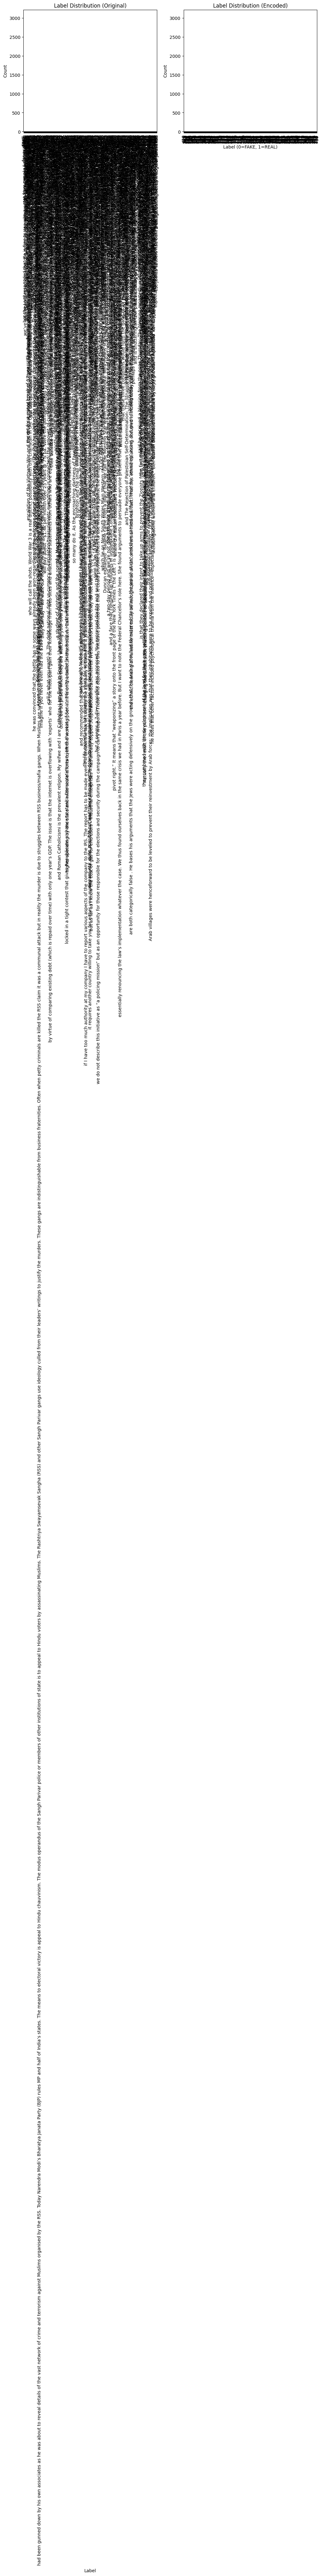

In [11]:
#visualization
# Visualize the label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before encoding
if 'label' in df_cleaned.columns:
    df_cleaned['label'].value_counts().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Label Distribution (Original)')
    axes[0].set_xlabel('Label')
    axes[0].set_ylabel('Count')

# After encoding
df_cleaned['label_encoded'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Label Distribution (Encoded)')
axes[1].set_xlabel('Label (0=FAKE, 1=REAL)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Load and preprocess the data
print("STEP 1: LOADING AND PREPROCESSING DATA")
print("="*60)

# Load the CSV file
df = pd.read_csv('fake_or_real_news.csv')

# Display basic info
print("Initial DataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Based on the warning, there are many unnamed columns
# Let's identify the relevant columns (usually first 3 columns contain text and label)
# Keep only the first 3 columns which should be: id, title/text, label
df_cleaned = df.iloc[:, :3].copy()

# Rename columns for clarity
df_cleaned.columns = ['id', 'text', 'label']  # Adjust based on your actual column names

print("\nCleaned DataFrame:")
print(df_cleaned.head())
print(f"\nCleaned shape: {df_cleaned.shape}")

# Handle missing values
print("\nSTEP 2: HANDLING MISSING VALUES")
print("="*60)
print("Missing values before cleaning:")
print(df_cleaned.isnull().sum())

# Fill missing text with empty string
df_cleaned['text'] = df_cleaned['text'].fillna('').astype(str)

# Drop rows with missing labels
df_cleaned = df_cleaned.dropna(subset=['label'])

print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

# Encode labels
print("\nSTEP 3: ENCODING CATEGORICAL VARIABLES")
print("="*60)
print("Unique labels:", df_cleaned['label'].unique())

# Create label encoding
label_mapping = {'FAKE': 0, 'REAL': 1}
df_cleaned['label_encoded'] = df_cleaned['label'].map(label_mapping)

# Check if any labels weren't mapped
if df_cleaned['label_encoded'].isnull().any():
    print("Warning: Some labels couldn't be mapped. Using alternative encoding...")
    # Alternative: Use LabelEncoder
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df_cleaned['label_encoded'] = le.fit_transform(df_cleaned['label'])
    print("Encoder classes:", le.classes_)

print("\nLabel distribution:")
print(df_cleaned['label_encoded'].value_counts())
print("\nPercentage distribution:")
print(df_cleaned['label_encoded'].value_counts(normalize=True) * 100)

# Remove duplicates
print("\nSTEP 4: REMOVING DUPLICATES")
print("="*60)
duplicates = df_cleaned['text'].duplicated().sum()
print(f"Number of duplicate texts: {duplicates}")

if duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['text'])
    print(f"After removing duplicates: {len(df_cleaned)} rows")

# Prepare features and target
X = df_cleaned['text']
y = df_cleaned['label_encoded']

print(f"\nFinal dataset shape: {df_cleaned.shape}")
print(f"Features (text): {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Split the data
print("\nSTEP 5: SPLITTING DATA INTO TRAIN AND TEST SETS")
print("="*60)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTesting set target distribution:")
print(y_test.value_counts(normalize=True))

# Save the cleaned dataset
df_cleaned.to_csv('cleaned_fake_news.csv', index=False)
print("\n✓ Cleaned dataset saved as 'cleaned_fake_news.csv'")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_cleaned['label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Label Distribution (Original)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df_cleaned['label_encoded'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Label Distribution (Encoded)')
axes[1].set_xlabel('Label (0=FAKE, 1=REAL)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("STEP 6: TRAINING NAIVE BAYES MODELS")
print("="*60)

# Create and train multiple Naive Bayes models
# Model 1: Multinomial Naive Bayes with Count Vectorizer
model1 = make_pipeline(
    CountVectorizer(stop_words='english', max_features=5000),
    MultinomialNB()
)

# Model 2: Multinomial Naive Bayes with TF-IDF
model2 = make_pipeline(
    TfidfVectorizer(stop_words='english', max_features=5000),
    MultinomialNB()
)

# Model 3: Bernoulli Naive Bayes with Count Vectorizer
model3 = make_pipeline(
    CountVectorizer(stop_words='english', max_features=5000, binary=True),
    BernoulliNB()
)

# Train all models
print("Training models...")
model1.fit(X_train, y_train)
print("✓ Model 1 trained (CountVectorizer + MultinomialNB)")

model2.fit(X_train, y_train)
print("✓ Model 2 trained (TfidfVectorizer + MultinomialNB)")

model3.fit(X_train, y_train)
print("✓ Model 3 trained (Binary CountVectorizer + BernoulliNB)")

# Make predictions
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

# Calculate accuracies
accuracy1 = accuracy_score(y_test, y_pred1)
accuracy2 = accuracy_score(y_test, y_pred2)
accuracy3 = accuracy_score(y_test, y_pred3)

print("\n" + "="*60)
print("STEP 7: MODEL EVALUATION RESULTS")
print("="*60)
print("\nModel Accuracies:")
print(f"Model 1 (CountVectorizer + MultinomialNB): {accuracy1:.4f} ({accuracy1*100:.2f}%)")
print(f"Model 2 (TfidfVectorizer + MultinomialNB): {accuracy2:.4f} ({accuracy2*100:.2f}%)")
print(f"Model 3 (Binary CountVectorizer + BernoulliNB): {accuracy3:.4f} ({accuracy3*100:.2f}%)")

# Find the best model
models = [model1, model2, model3]
accuracies = [accuracy1, accuracy2, accuracy3]
best_model_idx = np.argmax(accuracies)
best_model = models[best_model_idx]
best_predictions = [y_pred1, y_pred2, y_pred3][best_model_idx]

model_names = ['Count+Multinomial', 'TF-IDF+Multinomial', 'Binary+Bernoulli']
print(f"\n🏆 Best Model: {model_names[best_model_idx]} with accuracy {accuracies[best_model_idx]:.4f}")

# Detailed classification report for best model
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT - BEST MODEL")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions,
                          target_names=['FAKE', 'REAL']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title(f'Confusion Matrix - {model_names[best_model_idx]}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Metrics:")
print(f"True Negatives (Correctly predicted FAKE): {tn}")
print(f"False Positives (Incorrectly predicted REAL): {fp}")
print(f"False Negatives (Incorrectly predicted FAKE): {fn}")
print(f"True Positives (Correctly predicted REAL): {tp}")

# Calculate additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# ROC Curves
print("\n" + "="*60)
print("ROC CURVE ANALYSIS")
print("="*60)

plt.figure(figsize=(10, 8))

for i, (model, name) in enumerate(zip(models, model_names)):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)
    print(f"{name} ROC AUC: {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Naive Bayes Models Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Cross-validation
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy')

print(f"5-Fold CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Test on custom examples
print("\n" + "="*60)
print("TESTING ON CUSTOM EXAMPLES")
print("="*60)

custom_texts = [
    "Scientists discover breakthrough cure for cancer that big pharma doesn't want you to know about",
    "The president signed a new infrastructure bill today in a bipartisan ceremony",
    "Aliens found on Mars, NASA confirms in secret report leaked online",
    "Stock market closes higher amid positive economic indicators",
    "You won't believe what this celebrity did next! Click here to find out"
]

for text in custom_texts:
    prediction = best_model.predict([text])[0]
    probability = best_model.predict_proba([text])[0]

    pred_label = "REAL" if prediction == 1 else "FAKE"
    confidence = probability[prediction]

    print(f"\nText: {text[:100]}...")
    print(f"Prediction: {pred_label}")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"Class probabilities - FAKE: {probability[0]:.4f}, REAL: {probability[1]:.4f}")
    print("-" * 50)

# Final Summary
print("\n" + "="*60)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*60)

print(f"\nDataset Information:")
print(f"Total samples: {len(df_cleaned)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Class distribution: FAKE: {sum(y==0)}, REAL: {sum(y==1)}")

print(f"\nBest Model: {model_names[best_model_idx]}")
print(f"Test Accuracy: {accuracies[best_model_idx]:.4f} ({accuracies[best_model_idx]*100:.2f}%)")
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

print(f"\nModel Performance Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")

print(f"\nAll Model Accuracies:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

STEP 1: LOADING AND PREPROCESSING DATA
Initial DataFrame shape: (7795, 139)

First few rows:
                                                text label Unnamed: 2  \
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE        NaN   
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE        NaN   
2  U.S. Secretary of State John F. Kerry said Mon...  REAL        NaN   
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE        NaN   
4  It's primary day in New York and front-runners...  REAL        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 129 Unnamed: 1

/tmp/ipykernel_562/653223880.py:19: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fake_or_real_news.csv')


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.